# JTBD Analysis — ODI Opportunity Scoring & Segmentation
**Method:** Outcome-Driven Innovation (Ulwick)  
**Sample:** 989 kids, 67 desired outcomes

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'hot zone':              '#D85A30',
    'underserved':           '#EF9F27',
    'appropriately served':  '#1D9E75',
    'overserved':            '#378ADD',
    'seg1': '#534AB7',
    'seg2': '#D85A30',
    'seg3': '#1D9E75',
}

print('Libraries loaded.')

Libraries loaded.


## 1. Load data

In [10]:
# ── Update these paths if needed ──
SEGMENTS_FILE   = 'results_segments_forced.csv'         # output of segment_respondents.py
OPP_OVERALL     = 'opportunity_scores.csv' # output of opportunity_scores_calculator.py
OPP_PER_SEG     = 'opp_score_per_segment.csv' # output of opportunity_scores_per_segment.py

df      = pd.read_csv(SEGMENTS_FILE)
opp     = pd.read_csv(OPP_OVERALL)
opp_seg = pd.read_csv(OPP_PER_SEG)

print(f'Respondents : {len(df)}')
print(f'Segments    : {sorted(df.segment.unique())}')
print(f'Outcomes    : {len(opp)}')
df['segment'].value_counts().rename('kids').to_frame()

Respondents : 989
Segments    : [np.int64(1), np.int64(2), np.int64(3)]
Outcomes    : 67


,kids
segment,
3,381
1,368
2,240


## 2. Overall opportunity landscape
All 67 outcomes plotted — importance vs satisfaction. Hot zone = top-left.

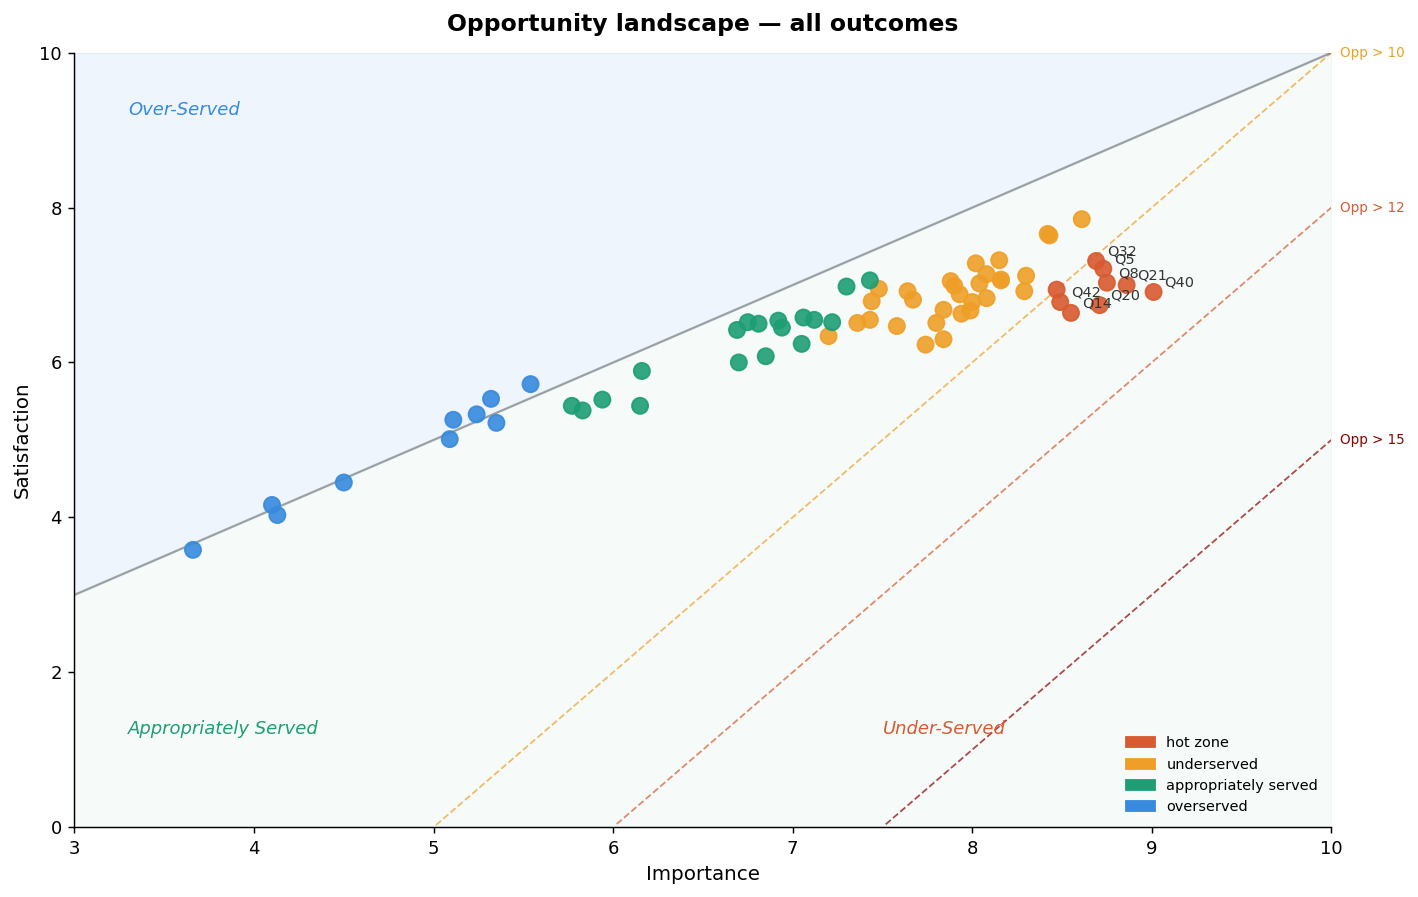

In [11]:
fig, ax = plt.subplots(figsize=(11, 7))

# ── background zone shading ──────────────────────────────────────────
x_range = np.linspace(3, 10, 300)

# Over-served region (satisfaction > importance) — light grey
ax.fill_between(x_range, x_range, 10, alpha=0.08, color='#378ADD', label='_nolegend_')

# Appropriately served / under-served region (satisfaction < importance)
ax.fill_between(x_range, 0, x_range, alpha=0.04, color='#1D9E75', label='_nolegend_')

# ── diagonal opportunity score lines ────────────────────────────────
# Opp score = importance + max(importance - satisfaction, 0)
# When importance > satisfaction: score = 2*importance - satisfaction
# → satisfaction = 2*importance - score  (rearranged)
for score, label, color in [(10, 'Opp > 10', '#EF9F27'),
                             (12, 'Opp > 12', '#D85A30'),
                             (15, 'Opp > 15', '#8B0000')]:
    sat_line = 2 * x_range - score
    # only draw where satisfaction > 0 and makes sense
    mask = (sat_line >= 0) & (sat_line <= 10)
    ax.plot(x_range[mask], sat_line[mask],
            ls='--', lw=1.0, color=color, alpha=0.7)
    # label at right end of line
    if mask.any():
        xi = x_range[mask][-1]
        yi = sat_line[mask][-1]
        ax.text(xi + 0.05, yi, label, fontsize=7.5, color=color, va='center')

# ── diagonal: satisfaction = importance (the main dividing line) ─────
ax.plot(x_range, x_range, '-', lw=1.2, color='#555', alpha=0.5)

# ── scatter dots ─────────────────────────────────────────────────────
zone_colors = opp['zone'].map(COLORS)
ax.scatter(opp['importance'], opp['satisfaction'],
           c=zone_colors, s=80, alpha=0.9, zorder=3)

# ── label top 8 outcomes ─────────────────────────────────────────────
top = opp.nlargest(8, 'opportunity_score')
for _, row in top.iterrows():
    ax.annotate(row['outcome'], (row['importance'], row['satisfaction']),
                textcoords='offset points', xytext=(6, 3),
                fontsize=8, color='#333')

# ── zone text labels ─────────────────────────────────────────────────
ax.text(3.3, 9.2,  'Over-Served',         fontsize=10, color='#378ADD',  style='italic')
ax.text(7.5, 1.2,  'Under-Served',        fontsize=10, color='#D85A30',  style='italic')
ax.text(3.3, 1.2,  'Appropriately Served',fontsize=10, color='#1D9E75',  style='italic')

# ── legend ───────────────────────────────────────────────────────────
legend = [mpatches.Patch(color=v, label=k)
          for k, v in COLORS.items() if k in opp['zone'].values]
ax.legend(handles=legend, fontsize=8, frameon=False)

# ── axes ─────────────────────────────────────────────────────────────
ax.set_xlim(3, 10)
ax.set_ylim(0, 10)
ax.set_xlabel('Importance', fontsize=11)
ax.set_ylabel('Satisfaction', fontsize=11)
ax.set_title('Opportunity landscape — all outcomes',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('landscape_overall.png', bbox_inches='tight')
plt.show()

## 3. Top 30 opportunities — overall

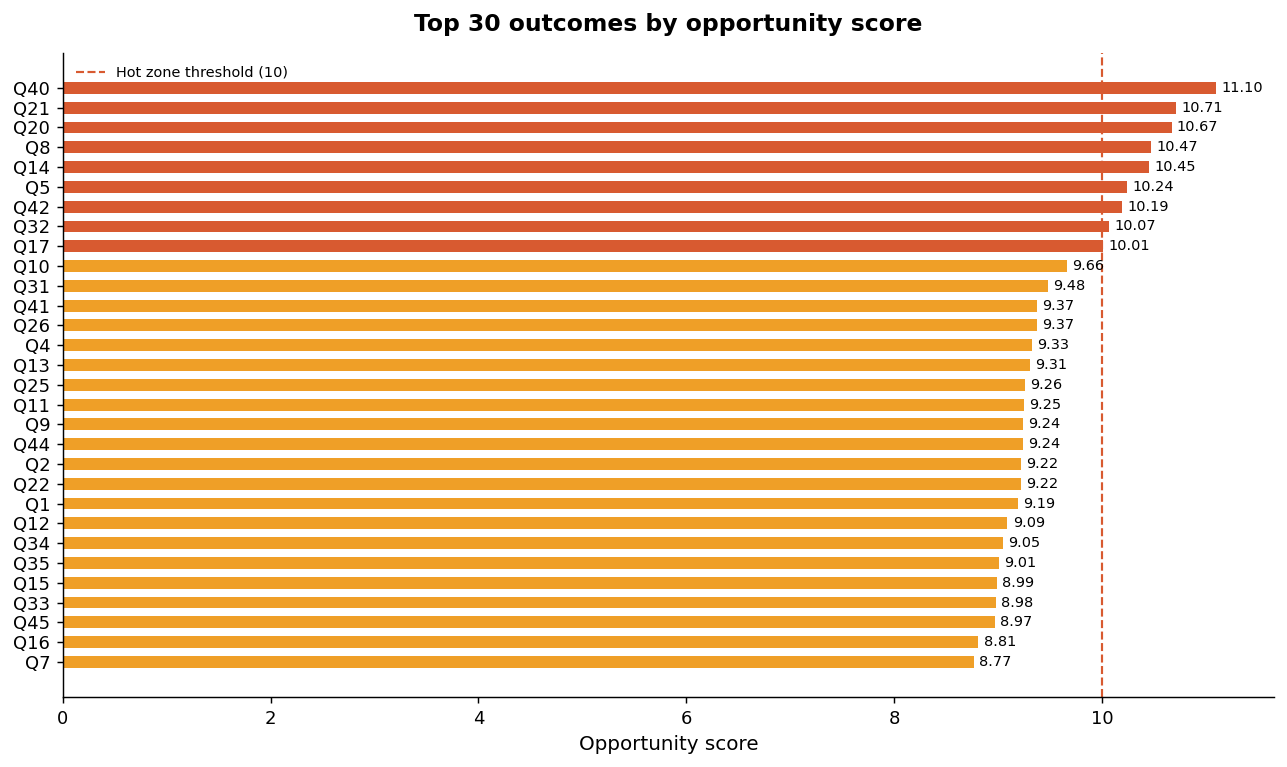

In [12]:
top30 = opp.nlargest(30, 'opportunity_score')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top30['outcome'][::-1], top30['opportunity_score'][::-1],
               color=[COLORS[z] for z in top30['zone'][::-1]], height=0.6)

ax.axvline(10, color='#D85A30', lw=1.2, ls='--', label='Hot zone threshold (10)')
ax.set_xlabel('Opportunity score', fontsize=11)
ax.set_title('Top 30 outcomes by opportunity score', fontsize=13, fontweight='bold', pad=12)

for bar, val in zip(bars, top30['opportunity_score'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)

ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig('top15_overall.png', bbox_inches='tight')
plt.show()

## 4. Segment profiles
Who is in each segment?

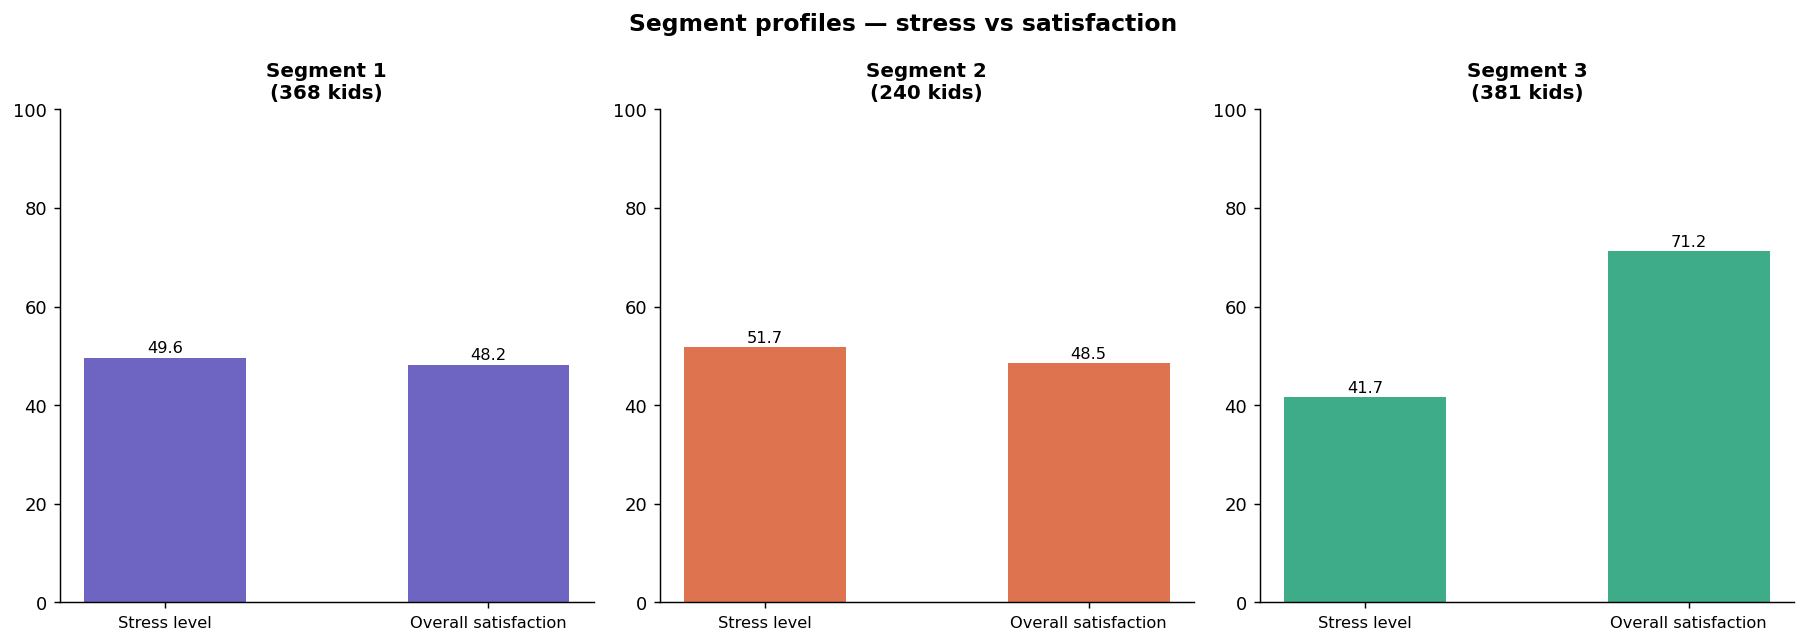

In [13]:
seg_colors = ['#534AB7', '#D85A30', '#1D9E75']
segments   = sorted(df['segment'].unique())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['stress_level', 'overall_satisfaction']
labels  = ['Stress level', 'Overall satisfaction']

for i, seg in enumerate(segments):
    seg_df = df[df['segment'] == seg]
    ax = axes[i]
    vals = [seg_df[m].mean() for m in metrics]
    bars = ax.bar(labels, vals, color=seg_colors[i], alpha=0.85, width=0.5)
    ax.set_ylim(0, 100)
    ax.set_title(f'Segment {seg}\n({len(seg_df)} kids)', fontsize=11, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}', ha='center', fontsize=9)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Segment profiles — stress vs satisfaction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_profiles.png', bbox_inches='tight')
plt.show()

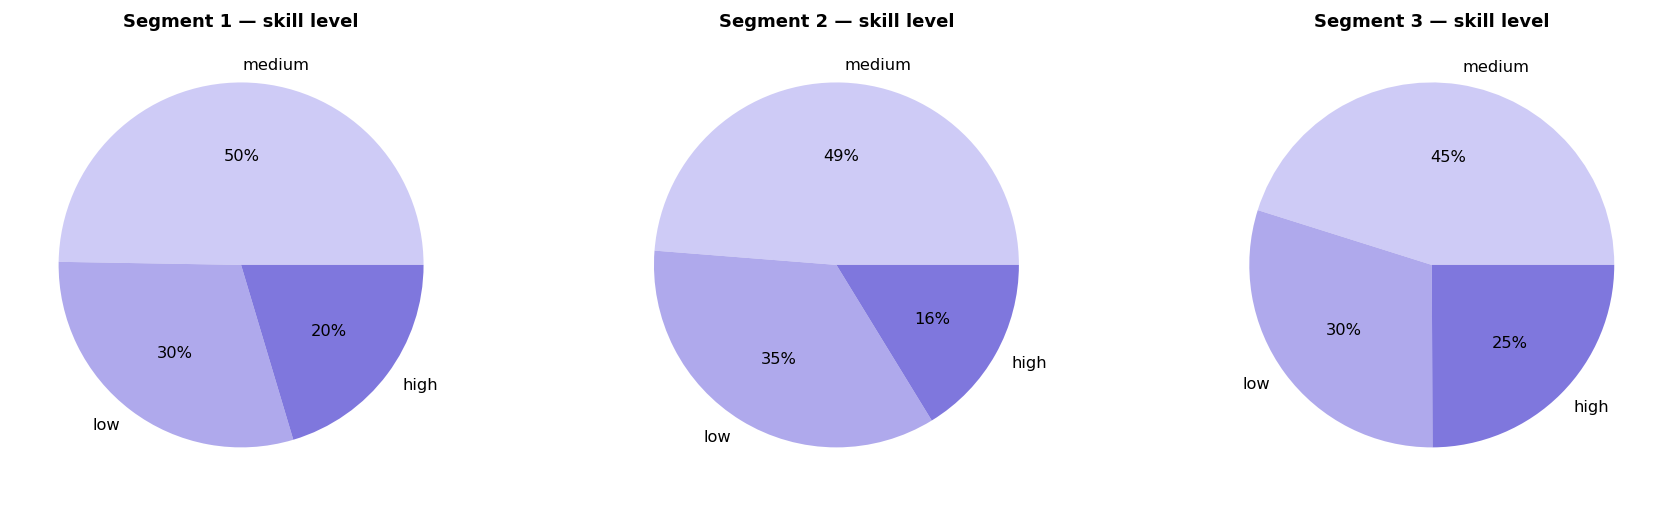

In [14]:
# Skill level distribution per segment
fig, axes = plt.subplots(1, len(segments), figsize=(14, 4))

for i, seg in enumerate(segments):
    seg_df = df[df['segment'] == seg]
    counts = seg_df['skill_level'].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.0f%%',
                colors=['#CECBF6','#AFA9EC','#7F77DD'],
                textprops={'fontsize': 9})
    axes[i].set_title(f'Segment {seg} — skill level', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('segment_skill.png', bbox_inches='tight')
plt.show()

## 5. Opportunity landscape per segment
Each segment gets its own map.

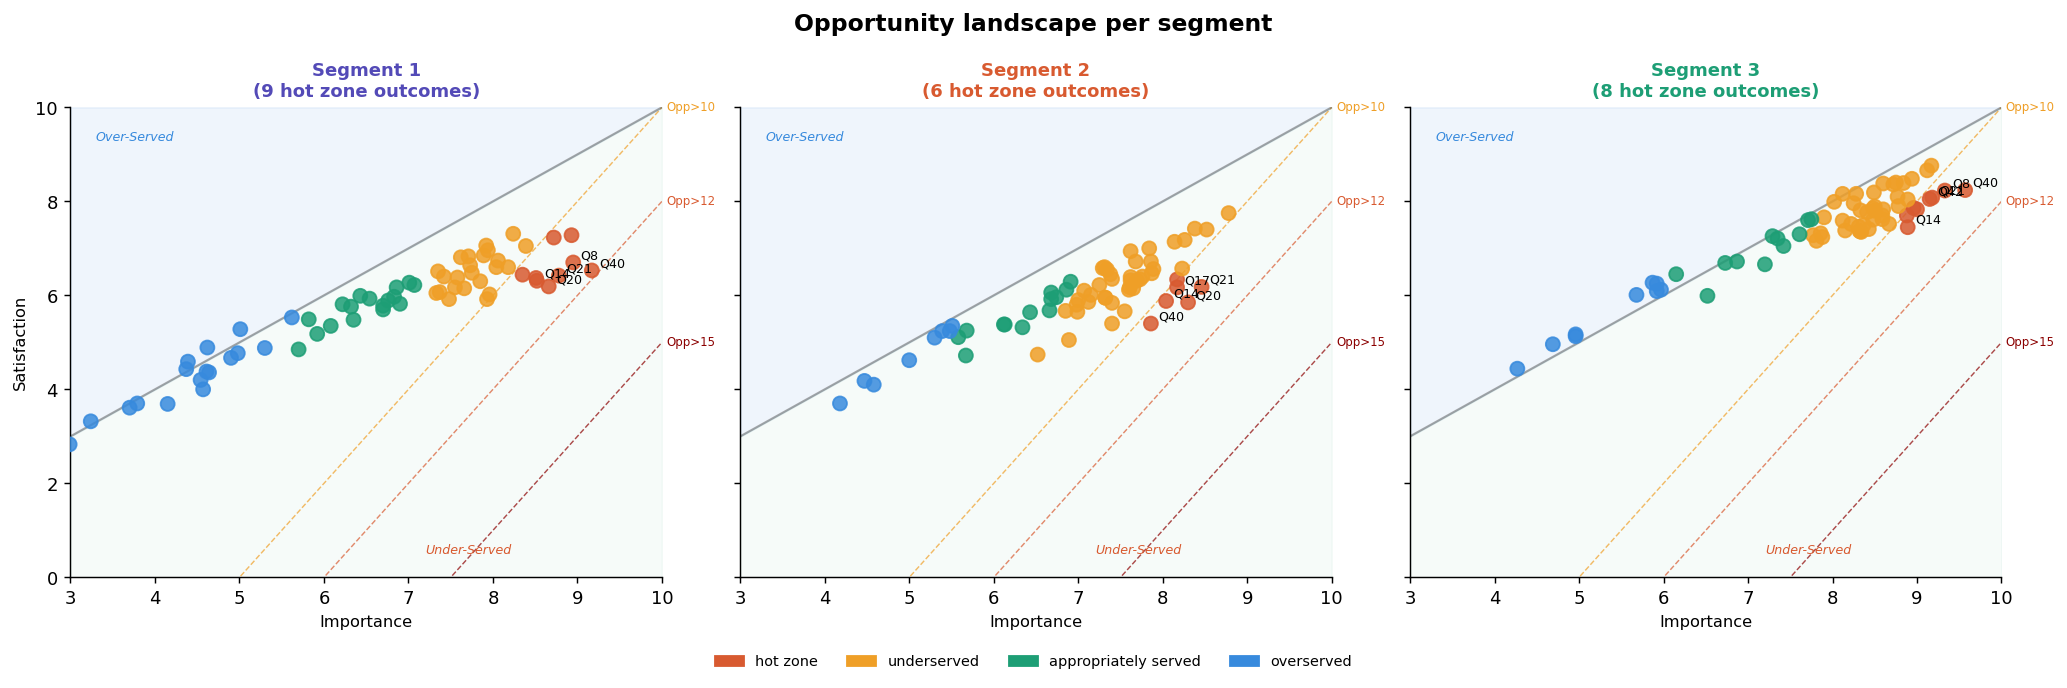

In [15]:
fig, axes = plt.subplots(1, len(segments), figsize=(16, 5), sharey=True)

x_range = np.linspace(3, 10, 300)

for i, seg in enumerate(segments):
    seg_opp = opp_seg[opp_seg['segment'] == seg]
    ax = axes[i]

    # ── background shading ──────────────────────────────────────────
    ax.fill_between(x_range, x_range, 10, alpha=0.08, color='#378ADD')   # over-served
    ax.fill_between(x_range, 0, x_range, alpha=0.04, color='#1D9E75')    # under-served

    # ── diagonal opportunity score lines ────────────────────────────
    for score, label, color in [(10, 'Opp>10', '#EF9F27'),
                                 (12, 'Opp>12', '#D85A30'),
                                 (15, 'Opp>15', '#8B0000')]:
        sat_line = 2 * x_range - score
        mask = (sat_line >= 0) & (sat_line <= 10)
        ax.plot(x_range[mask], sat_line[mask],
                ls='--', lw=0.8, color=color, alpha=0.7)
        if mask.any():
            xi = x_range[mask][-1]
            yi = sat_line[mask][-1]
            ax.text(xi + 0.05, yi, label, fontsize=6.5, color=color, va='center')

    # ── main diagonal line (satisfaction = importance) ───────────────
    ax.plot(x_range, x_range, '-', lw=1.2, color='#555', alpha=0.5)

    # ── scatter dots ─────────────────────────────────────────────────
    colors = seg_opp['zone'].map(COLORS)
    ax.scatter(seg_opp['importance'], seg_opp['satisfaction'],   # ← fixed x/y
               c=colors, s=60, alpha=0.85, zorder=3)

    # ── label top 5 ──────────────────────────────────────────────────
    for _, row in seg_opp.nlargest(5, 'opportunity_score').iterrows():
        ax.annotate(row['outcome'], (row['importance'], row['satisfaction']),  # ← fixed x/y
                    textcoords='offset points', xytext=(4, 2), fontsize=7)

    # ── zone text labels ─────────────────────────────────────────────
    ax.text(3.3, 9.3, 'Over-Served',    fontsize=7, color='#378ADD', style='italic')
    ax.text(7.2, 0.5, 'Under-Served',   fontsize=7, color='#D85A30', style='italic')

    # ── title & axes ─────────────────────────────────────────────────
    hot_count = len(seg_opp[seg_opp['zone'] == 'hot zone'])
    ax.set_title(f'Segment {seg}\n({hot_count} hot zone outcomes)',
                 fontsize=10, fontweight='bold', color=seg_colors[i])
    ax.set_xlabel('Importance', fontsize=9)    # ← fixed label
    ax.set_xlim(3, 10)
    ax.set_ylim(0, 10)
    if i == 0:
        ax.set_ylabel('Satisfaction', fontsize=9)  # ← fixed label

legend = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()
          if k in opp_seg['zone'].values]
fig.legend(handles=legend, fontsize=8, frameon=False,
           loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Opportunity landscape per segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('landscape_per_segment.png', bbox_inches='tight')
plt.show()

## 6. Top 30 opportunities per segment — side by side

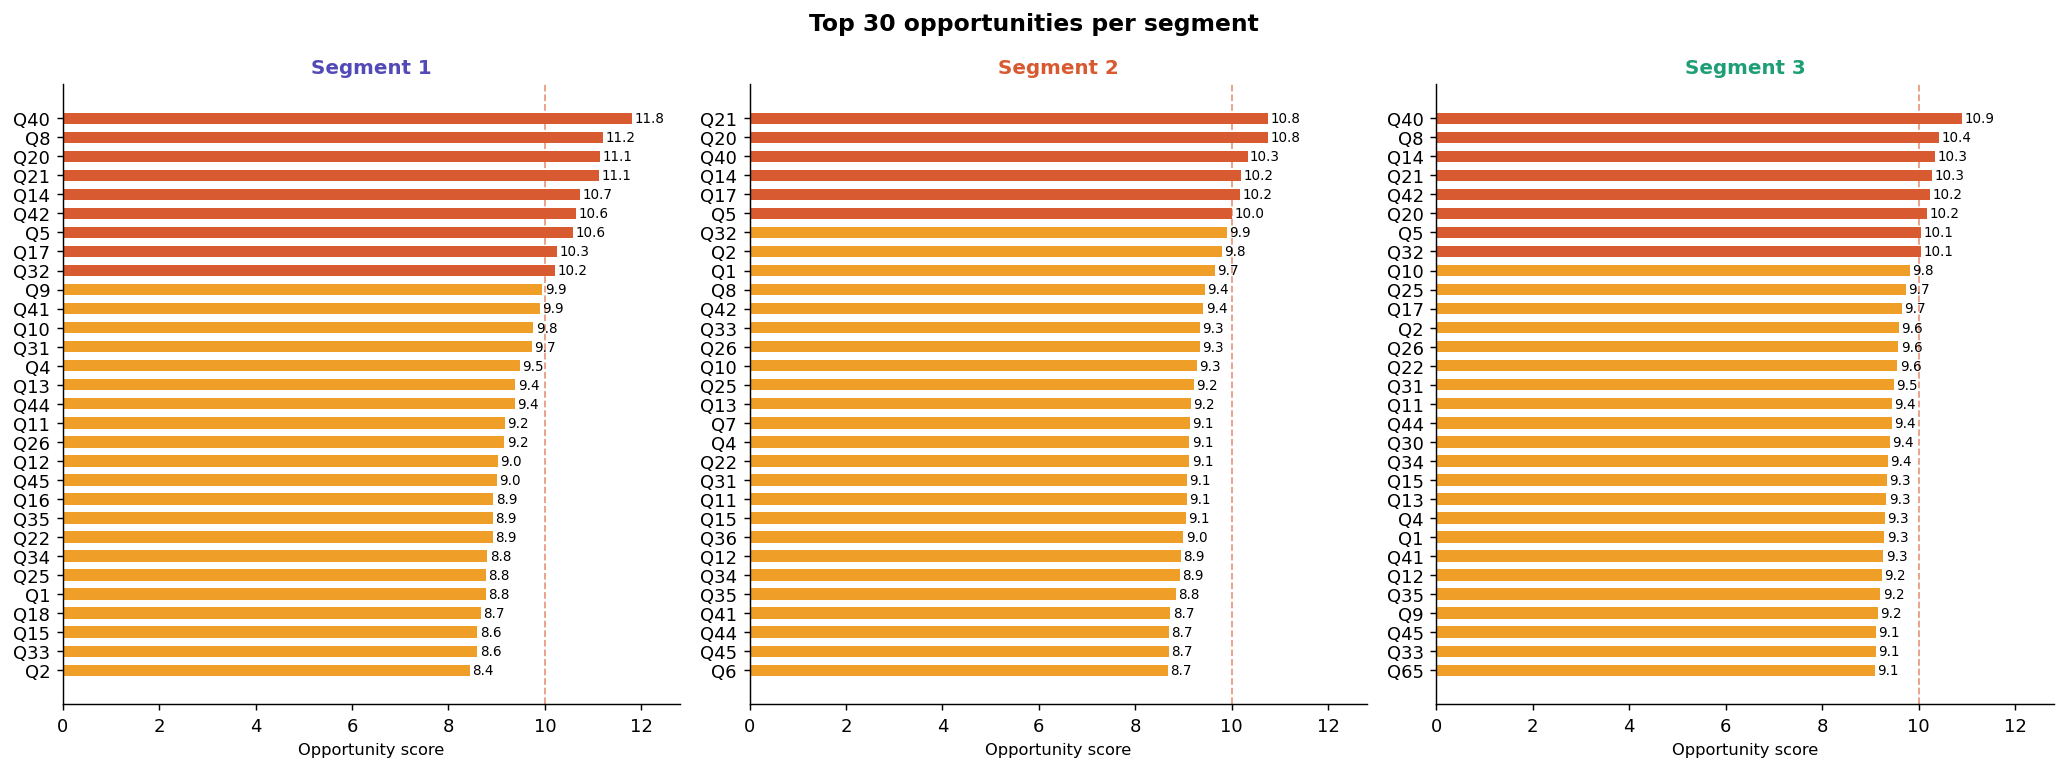

In [9]:
fig, axes = plt.subplots(1, len(segments), figsize=(16, 6))

for i, seg in enumerate(segments):
    seg_opp = opp_seg[opp_seg['segment'] == seg].nlargest(30, 'opportunity_score')
    ax = axes[i]

    bars = ax.barh(seg_opp['outcome'][::-1], seg_opp['opportunity_score'][::-1],
                   color=[COLORS[z] for z in seg_opp['zone'][::-1]], height=0.6)
    ax.axvline(10, color='#D85A30', lw=1, ls='--', alpha=0.6)

    for bar, val in zip(bars, seg_opp['opportunity_score'][::-1]):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=7.5)

    ax.set_title(f'Segment {seg}', fontsize=11, fontweight='bold', color=seg_colors[i])
    ax.set_xlabel('Opportunity score', fontsize=9)
    ax.set_xlim(0, opp_seg['opportunity_score'].max() + 1)

fig.suptitle('Top 30 opportunities per segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('top30_per_segment.png', bbox_inches='tight')
plt.show()

## 7. Zone distribution per segment

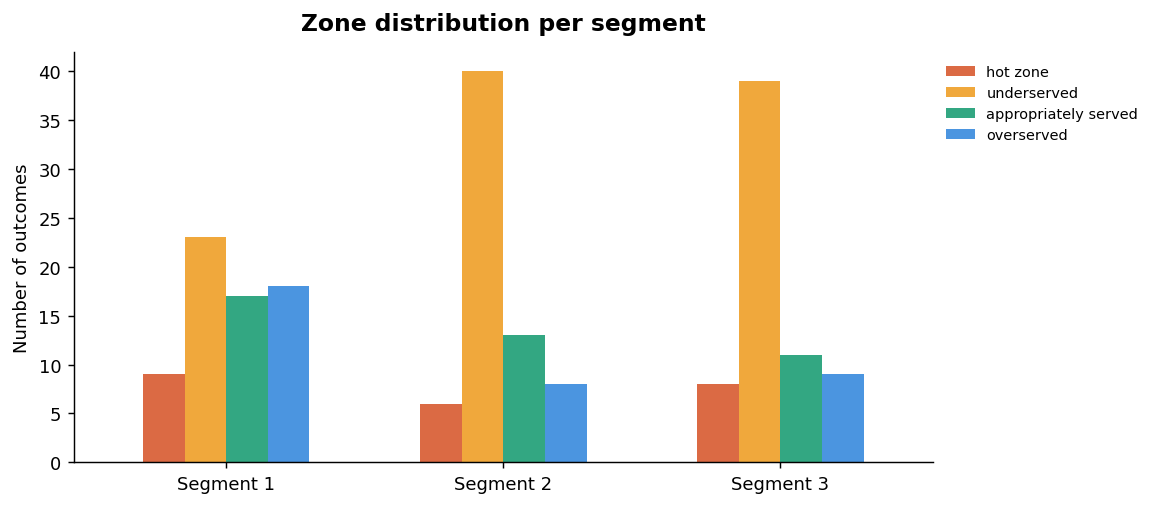

In [10]:
zone_order = ['hot zone', 'underserved', 'appropriately served', 'overserved']
zone_data = []
for seg in segments:
    counts = opp_seg[opp_seg['segment'] == seg]['zone'].value_counts()
    for z in zone_order:
        zone_data.append({'segment': f'Segment {seg}', 'zone': z, 'count': counts.get(z, 0)})

zone_df = pd.DataFrame(zone_data)
pivot = zone_df.pivot(index='segment', columns='zone', values='count')[zone_order]

fig, ax = plt.subplots(figsize=(9, 4))
pivot.plot(kind='bar', ax=ax, color=[COLORS[z] for z in zone_order],
           width=0.6, alpha=0.9)

ax.set_xlabel('')
ax.set_ylabel('Number of outcomes', fontsize=10)
ax.set_title('Zone distribution per segment', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=8, frameon=False, bbox_to_anchor=(1, 1))
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('zone_distribution.png', bbox_inches='tight')
plt.show()

## 8. Name your segments
Based on the profiles and opportunity landscapes above, we give each segment a name and description.

We name based on this structure:
- **Name** 
- **Who they are** 
- **What they need most** 
- **Design implication** 

In [14]:
# ── Fill these in after looking at the charts above ──

segment_names = {
    1: "Ambitious Performance Seekers",
    2: "Safety and Support Seekers",
    3: "Team-Oriented Growth Seekers",
}

segment_descriptions = {
    1: "Performance-oriented players who want to compete regularly, win games and visibly improve their skills. They need a structured and serious training environment, clear guidance from the coach and better support in achieving measurable sporting progress.",
    2: "Players with relatively high stress who need psychological safety and respectful treatment within the team. They want to make mistakes without being shouted at, embarrassed or publicly criticized, and they need clear, constructive feedback that helps them improve",
    3: "Generally satisfied and low-stress players who still want to compete, develop and improve their performance. At the same time, they value a respectful, fair and cooperative team environment where teammates support one another and social connection is encouraged.",
}

# Print summary card per segment
for seg in segments:
    seg_df  = df[df['segment'] == seg]
    seg_opp = opp_seg[opp_seg['segment'] == seg]
    top3    = seg_opp.nlargest(3, 'opportunity_score')
    hot     = len(seg_opp[seg_opp['zone'] == 'hot zone'])

    print(f"{'='*50}")
    print(f"SEGMENT {seg} — {segment_names[seg]}")
    print(f"  Kids        : {len(seg_df)} ({len(seg_df)/len(df)*100:.1f}%)")
    print(f"  Avg age     : {seg_df['age'].mean():.1f}")
    print(f"  Stress      : {seg_df['stress_level'].mean():.1f}")
    print(f"  Satisfaction: {seg_df['overall_satisfaction'].mean():.1f}")
    print(f"  Hot zone    : {hot} outcomes")
    print(f"  Top needs   :")
    for _, row in top3.iterrows():
        print(f"    {row.outcome}: {row.opportunity_score:.2f} ({row.zone})")
    print(f"  Description : {segment_descriptions[seg]}")
print('='*50)

SEGMENT 1 — Ambitious Performance Seekers
  Kids        : 368 (37.2%)
  Avg age     : 11.6
  Stress      : 49.6
  Satisfaction: 48.2
  Hot zone    : 9 outcomes
  Top needs   :
    Q40: 11.81 (hot zone)
    Q8: 11.20 (hot zone)
    Q20: 11.14 (hot zone)
  Description : Performance-oriented players who want to compete regularly, win games and visibly improve their skills. They need a structured and serious training environment, clear guidance from the coach and better support in achieving measurable sporting progress.
SEGMENT 2 — Safety and Support Seekers
  Kids        : 240 (24.3%)
  Avg age     : 10.5
  Stress      : 51.7
  Satisfaction: 48.5
  Hot zone    : 6 outcomes
  Top needs   :
    Q21: 10.75 (hot zone)
    Q20: 10.75 (hot zone)
    Q40: 10.33 (hot zone)
  Description : Players with relatively high stress who need psychological safety and respectful treatment within the team. They want to make mistakes without being shouted at, embarrassed or publicly criticized, and they need 

## 9. Final summary — what should the club do?
- Still in progress ...

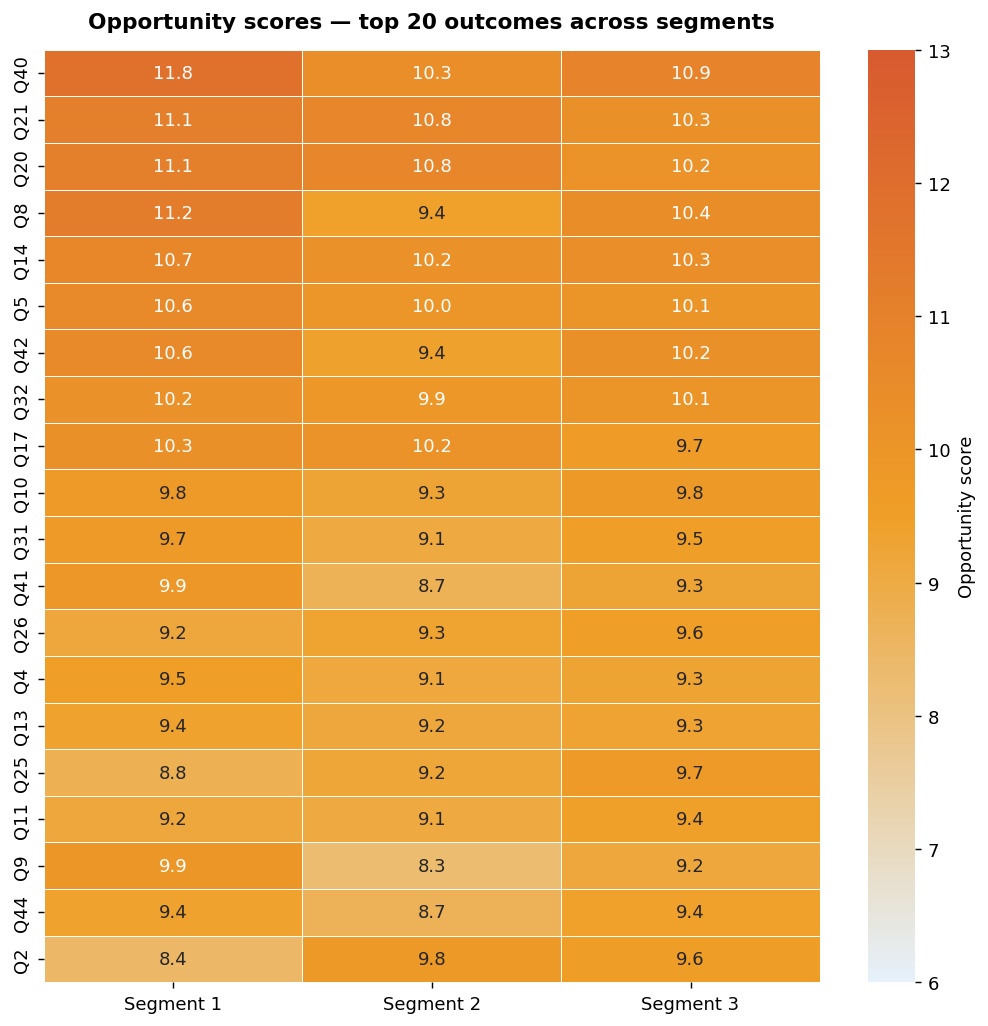

In [13]:
# Heatmap: opportunity scores across all segments for top 20 outcomes
top20 = opp.nlargest(20, 'opportunity_score')['outcome'].tolist()

pivot = opp_seg[opp_seg['outcome'].isin(top20)].pivot(
    index='outcome', columns='segment', values='opportunity_score'
).reindex(top20)
pivot.columns = [f'Segment {s}' for s in pivot.columns]

fig, ax = plt.subplots(figsize=(8, 8))
cmap = LinearSegmentedColormap.from_list('opp', ['#E6F1FB', '#EF9F27', '#D85A30'])
sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, linewidths=0.4,
            ax=ax, cbar_kws={'label': 'Opportunity score'}, vmin=6, vmax=13)

ax.set_title('Opportunity scores — top 20 outcomes across segments',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('heatmap_segments.png', bbox_inches='tight')
plt.show()